In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

# Dataset

In [32]:
df = pd.read_csv("cardekho.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


# Dataset information

In [33]:
print("Rows and Columns :", df.shape)
df.info()
df.describe()

Rows and Columns : (8128, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


# Check Missing Values

In [34]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),221
engine,221


# Fill missing values

In [35]:
df["mileage(km/ltr/kg)"].fillna(df["mileage(km/ltr/kg)"].median(), inplace=True)
df["engine"].fillna(df["engine"].median(), inplace=True)
df["max_power"] = pd.to_numeric(df["max_power"], errors='coerce')
df["max_power"].fillna(df["max_power"].median(), inplace=True)
df["seats"].fillna(df["seats"].mode()[0], inplace=True)
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


# Standardise categorical values

In [36]:
df["fuel"] = df["fuel"].str.title()
df["seller_type"] = df["seller_type"].str.title()
df["transmission"] = df["transmission"].str.title()
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


# Feature engineering

In [37]:
current_year = 2026

df["car_age"] = current_year - df["year"]
df["brand"] = df["name"].str.split().str[0]

df[["name","brand"]].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


# Drop Unnecessary coloumns

In [38]:
df.drop(["name","year"], axis=1, inplace=True)

df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,12,Maruti
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12,Skoda
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,20,Honda
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,16,Hyundai
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,19,Maruti


# Distribution of selling price

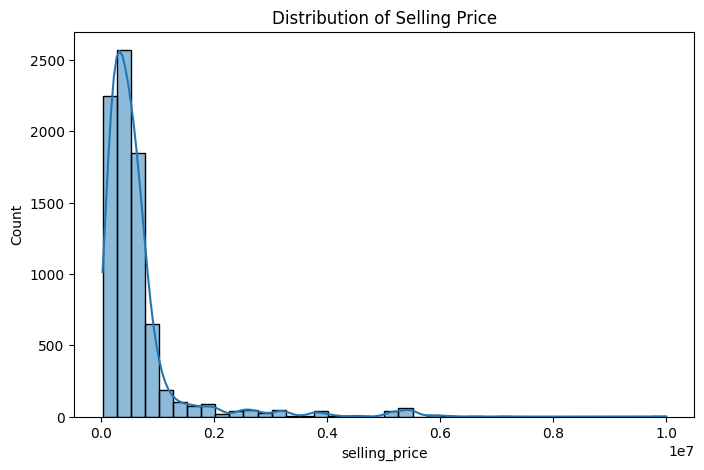

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], bins=40, kde=True)

plt.title("Distribution of Selling Price")

plt.show()

# Boxplot (Selling Price vs Fuel Type)

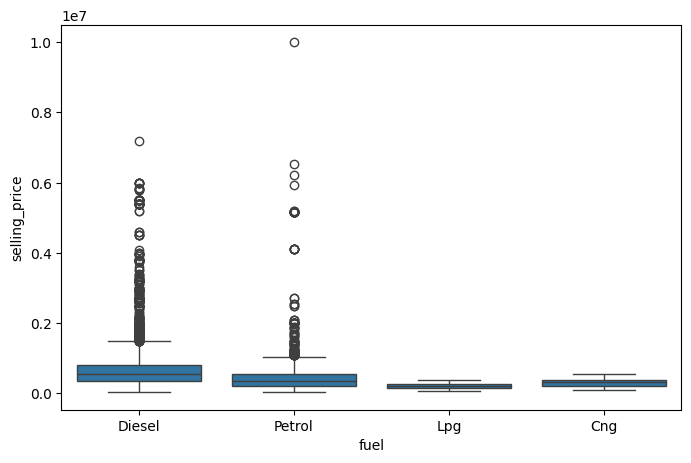

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x="fuel", y="selling_price", data=df)

plt.show()

# Scatter Plot

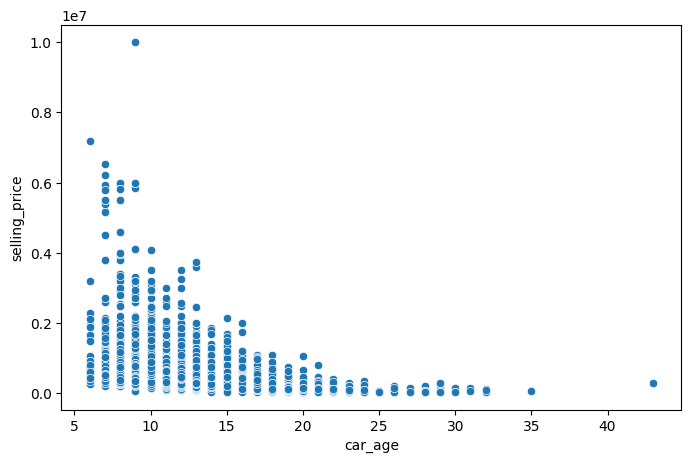

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="car_age", y="selling_price", data=df)

plt.show()

# Correlation Heatmap

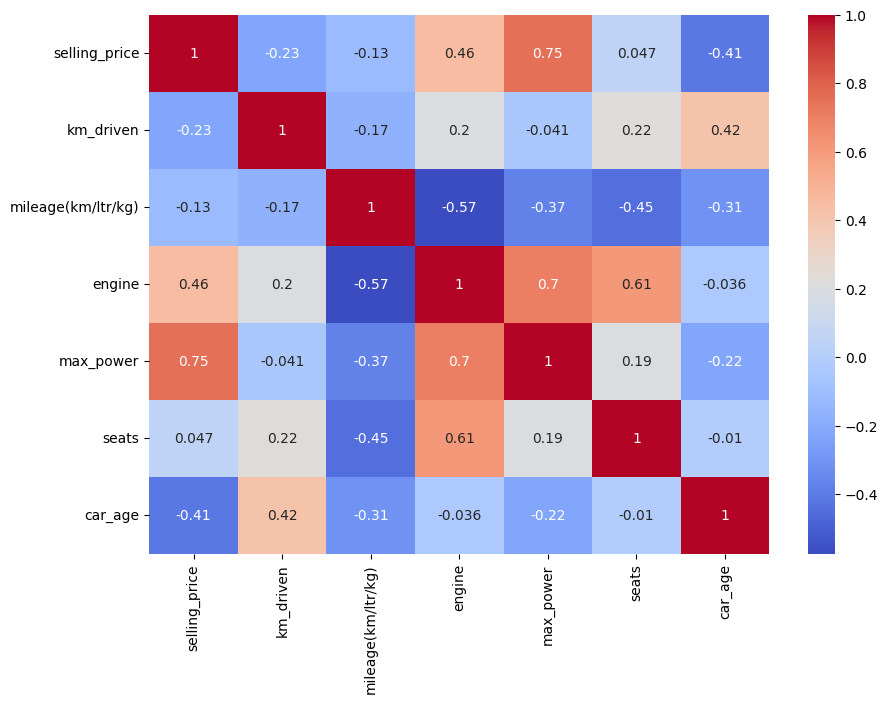

In [42]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

# Define Features

In [43]:
X = df.drop("selling_price", axis=1)

y = df["selling_price"]

# Identify Numerical & Categorical Columns

In [44]:
categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

print(categorical_cols)

print(numerical_cols)

Index(['fuel', 'seller_type', 'transmission', 'owner', 'brand'], dtype='object')
Index(['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats',
       'car_age'],
      dtype='object')


# Preprocessing Pipeline

In [45]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Linear Regression Model

In [47]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

# Evaluate Linear Regression

In [48]:
mae = mean_absolute_error(y_test, linear_pred)

rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

r2 = r2_score(y_test, linear_pred)

print("Linear Regression")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

Linear Regression
MAE : 273324.0796567426
RMSE : 446616.4680387159
R2 Score : 0.6956964082927205


# Random Forest Model

In [49]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Evaluate Random Forest

In [50]:
mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("Random Forest")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

Random Forest
MAE : 67694.0948454831
RMSE : 142223.06561173475
R2 Score : 0.969141295894816


# Feature importance

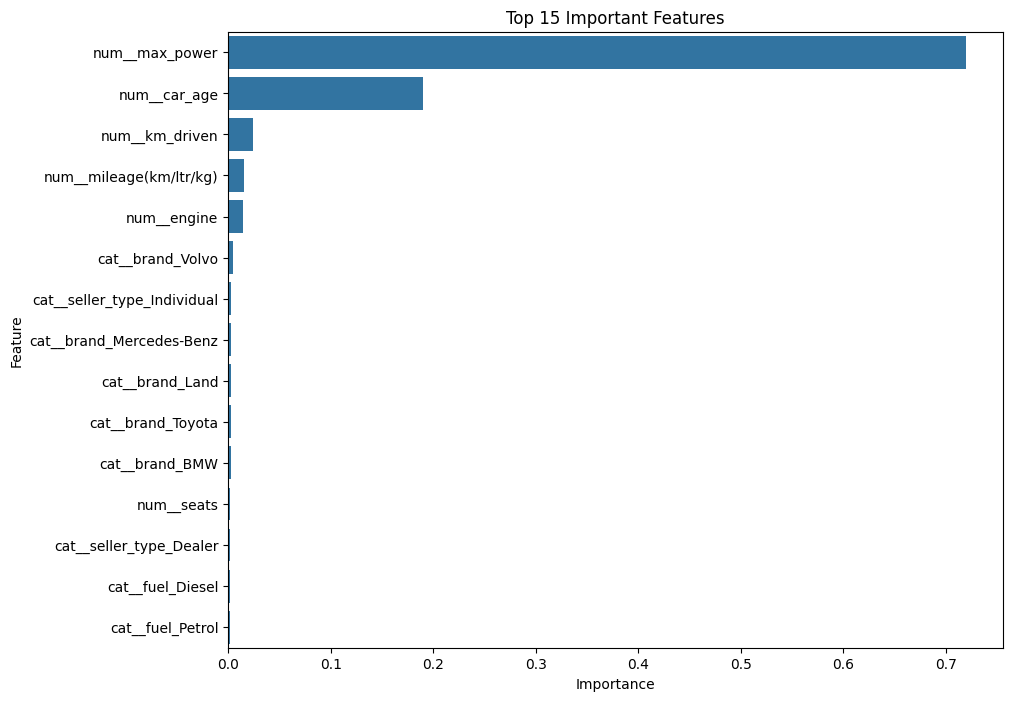

In [51]:
encoder = rf_model.named_steps["preprocessor"]

feature_names = encoder.get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

# Conclusion

In [52]:
print("Project Completed Successfully")

print()

print("Models Used:")
print("1. Linear Regression")
print("2. Random Forest Regressor")

print()

print("Random Forest generally performs better for nonlinear relationships and is expected to achieve a higher R² score with lower MAE and RMSE.")

Project Completed Successfully

Models Used:
1. Linear Regression
2. Random Forest Regressor

Random Forest generally performs better for nonlinear relationships and is expected to achieve a higher R² score with lower MAE and RMSE.
